In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/FYP


archive.zip  Relief.ipynb


In [ ]:
import os
import zipfile

# --- CONFIGURATION ---
ZIP_PATH = '/content/drive/MyDrive/FYP/archive.zip'
EXTRACT_PATH = '/content/dataset'

# Safety check
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP file not found at: {ZIP_PATH}")

# Create extraction directory
os.makedirs(EXTRACT_PATH, exist_ok=True)

print(f"📂 Unzipping from: {ZIP_PATH}")

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✅ Unzipping complete.")

# Verify extracted structure
print("📁 Extracted top-level folders:")
print(os.listdir(EXTRACT_PATH))


📂 Unzipping from: /content/drive/MyDrive/FYP/archive.zip
✅ Unzipping complete.
📁 Extracted top-level folders:
['ISIC2018_Task3_Training_LesionGroupings.csv', 'ISIC2018_Task3_Training_Input', 'ISIC2018_Task3_Validation_GroundTruth', 'ISIC2018_Task3_Training_GroundTruth', 'ISIC2018_Task3_Test_Input', 'ISIC2018_Task3_Test_GroundTruth', 'ISIC2018_Task3_Validation_Input']


In [ ]:
# Inspect dataset structure
for root, dirs, files in os.walk(EXTRACT_PATH):
    print(f"📂 {root}")
    print(f"   Subfolders: {dirs[:5]}")
    print(f"   Files: {files[:5]}")
    break


📂 /content/dataset
   Subfolders: ['ISIC2018_Task3_Training_Input', 'ISIC2018_Task3_Validation_GroundTruth', 'ISIC2018_Task3_Training_GroundTruth', 'ISIC2018_Task3_Test_Input', 'ISIC2018_Task3_Test_GroundTruth']
   Files: ['ISIC2018_Task3_Training_LesionGroupings.csv']


In [ ]:
import pandas as pd
import os

TRAIN_LABELS_PATH = os.path.join(
    "/content/dataset",
    "ISIC2018_Task3_Training_GroundTruth",
    "ISIC2018_Task3_Training_GroundTruth",
    "ISIC2018_Task3_Training_GroundTruth.csv"
)



train_df = pd.read_csv(TRAIN_LABELS_PATH)
train_df.head()


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Data Exploration

In [ ]:
train_df["label"].value_counts()



,count
label,
NV,6705
MEL,1113
BKL,1099
BCC,514
AKIEC,327
VASC,142
DF,115


In [ ]:
import os

BASE_IMG_DIR = "/content/dataset/ISIC2018_Task3_Training_Input"
print(os.listdir(BASE_IMG_DIR))




['ISIC2018_Task3_Training_Input']


In [ ]:
class_counts_df = class_counts.reset_index()
class_counts_df.columns = ["Class", "Number of Datapoints"]
class_counts_df


,Class,Number of Datapoints
0,NV,6705
1,MEL,1113
2,BKL,1099
3,BCC,514
4,AKIEC,327
5,VASC,142
6,DF,115


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=class_counts_df)

NameError: name 'class_counts_df' is not defined

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

IMG_DIR = "/content/dataset/ISIC2018_Task3_Training_Input/ISIC2018_Task3_Training_Input"

def show_class_samples(label, n=3):
    imgs = train_df[train_df["label"] == label]["image"].sample(n)
    plt.figure(figsize=(12,4))
    for i, img_id in enumerate(imgs):
        img = Image.open(os.path.join(IMG_DIR, img_id + ".jpg"))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")
    plt.show()

for cls in train_df["label"].unique():
    show_class_samples(cls, n=2)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import numpy as np

widths, heights = [], []

for img_id in train_df["image"].sample(200):
    img = Image.open(os.path.join(IMG_DIR, img_id + ".jpg"))
    w, h = img.size
    widths.append(w)
    heights.append(h)

print(f"Avg width: {np.mean(widths):.1f}")
print(f"Avg height: {np.mean(heights):.1f}")


Avg width: 600.0
Avg height: 450.0


In [ ]:
print("Missing values:\n", train_df.isnull().sum())
print("Duplicate images:", train_df["image"].duplicated().sum())


Missing values:
 image    0
MEL      0
NV       0
BCC      0
AKIEC    0
BKL      0
DF       0
VASC     0
label    0
dtype: int64
Duplicate images: 0


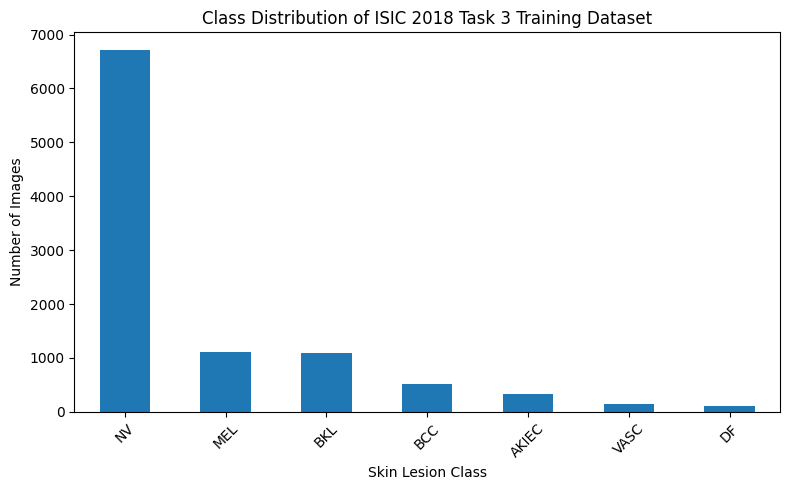

In [ ]:
import matplotlib.pyplot as plt

class_counts = train_df["label"].value_counts()

plt.figure(figsize=(8,5))
class_counts.plot(kind="bar")
plt.title("Class Distribution of ISIC 2018 Task 3 Training Dataset")
plt.xlabel("Skin Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# --- FINALIZING THE SPLIT (DO THIS ONCE) ---
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# 1. Setup
DATA_PATH = '/content/dataset' # Ensure this points to where you unzipped ISIC
SAVE_DIR = '/content/drive/My Drive/RELEIF_Project/splits'
os.makedirs(SAVE_DIR, exist_ok=True)

# 2. Load and Prep
df = pd.read_csv(os.path.join(DATA_PATH, 'ISIC2018_Task3_Training_GroundTruth.csv'))
classes = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
df['label'] = df[classes].idxmax(axis=1)

# 3. The "Sacred" Split (20% Test, Stratified)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df['image'], df['label'],
    test_size=0.20,
    stratify=df['label'],
    random_state=42 # CRITICAL: Fixed Seed
)

# 4. Save to Drive
# We only save IDs/Labels. We load images on demand later.
print("💾 Saving Splits to Drive...")
train_df = pd.DataFrame({'image': X_train_full, 'label': y_train_full})
test_df = pd.DataFrame({'image': X_test, 'label': y_test})

train_df.to_csv(f'{SAVE_DIR}/train_master.csv', index=False)
test_df.to_csv(f'{SAVE_DIR}/test_master.csv', index=False)

print(f"✅ DONE. \nTrain Size: {len(train_df)}\nTest Size: {len(test_df)}")
print("You may now proceed to Diffusion Training using 'train_master.csv' ONLY.")

Data Split

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

CSV_PATH = TRAIN_LABELS_PATH

# --- 1. Load Data ---
df = pd.read_csv(CSV_PATH)

# Handling ISIC format: It usually has One-Hot Encoding (columns like MEL, NV, BCC...)
# We need to convert this to a single 'label' column for stratification.
class_cols = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

# Check if these columns exist, otherwise guess the label column
if set(class_cols).issubset(df.columns):
    df['label'] = df[class_cols].idxmax(axis=1)
    print("✅ Converted One-Hot labels to Single Column.")
else:
    # Fallback if your CSV is different (e.g., 'dx' column in HAM10000)
    print("⚠️ Standard columns not found. Using 'dx' or similar if available.")
    # Add manual fix here if needed

# --- 2. The Split ---
print("✂️ Performing Train (70%) / Val (10%) / Test (20%) Split...")

# Split 1: Train_Full (80%) + Test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df['image'], df['label'],
    test_size=0.20,
    stratify=df['label'],
    random_state=42 # FIXED SEED IS CRITICAL FOR THESIS
)

# Split 2: Train (70% total) + Val (10% total) -> 0.125 of 0.8 = 0.1
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.125,
    stratify=y_train_full,
    random_state=42
)

# --- 3. Save to Drive ---
SPLIT_DIR = '/content/drive/MyDrive/FYP/splits'
os.makedirs(SPLIT_DIR, exist_ok=True)

# Create handy dataframes
train_df = pd.DataFrame({'image': X_train, 'label': y_train})
val_df = pd.DataFrame({'image': X_val, 'label': y_val})
test_df = pd.DataFrame({'image': X_test, 'label': y_test})

train_df.to_csv(f'{SPLIT_DIR}/train_split.csv', index=False)
val_df.to_csv(f'{SPLIT_DIR}/val_split.csv', index=False)
test_df.to_csv(f'{SPLIT_DIR}/test_split.csv', index=False)

print(f"✅ Splits Saved to {SPLIT_DIR}")
print(f"   Train Size: {len(train_df)}")
print(f"   Val Size:   {len(val_df)}")
print(f"   Test Size:  {len(test_df)}")

✅ Converted One-Hot labels to Single Column.
✂️ Performing Train (70%) / Val (10%) / Test (20%) Split...
✅ Splits Saved to /content/drive/MyDrive/FYP/splits
   Train Size: 7010
   Val Size:   1002
   Test Size:  2003


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import pandas as pd

# --- 1. AUTO-DETECT IMAGE DIRECTORY ---
# We search for the first folder containing at least 5 JPGs
base_search_path = '/content/dataset'
IMAGE_DIR = None

print(f"🕵️ Searching for images inside {base_search_path}...")

for root, dirs, files in os.walk(base_search_path):
    jpg_count = sum(1 for f in files if f.lower().endswith('.jpg'))
    if jpg_count > 5:
        IMAGE_DIR = root
        print(f"✅ FOUND IMAGES IN: {IMAGE_DIR}")
        print(f"   (Contains {jpg_count} images)")
        break

if IMAGE_DIR is None:
    # If no folder found, maybe they are in the root?
    print("⚠️ No subfolder found. Checking root...")
    IMAGE_DIR = base_search_path

# --- 2. RELOAD SPLIT ---
SPLIT_DIR = '/content/drive/MyDrive/FYP/splits'
train_path = os.path.join(SPLIT_DIR, 'train_split.csv')

if not os.path.exists(train_path):
    print("❌ ERROR: train_split.csv missing. Run the SPLIT block first.")
else:
    train_df = pd.read_csv(train_path)
    print(f"📚 Loaded Train Split: {len(train_df)} rows")

    # --- 3. ROBUST RESOLUTION CHECK ---
    print("\n🔍 Checking Image Resolutions...")
    widths, heights = [], []

    # We explicitly check for file existence to debug
    sample_imgs = train_df['image'].sample(min(100, len(train_df)), random_state=42)

    success_count = 0
    error_count = 0

    for img_id in tqdm(sample_imgs):
        # Try both with and without .jpg extension
        fname = str(img_id)
        if not fname.lower().endswith('.jpg'):
            fname += '.jpg'

        path = os.path.join(IMAGE_DIR, fname)

        try:
            with Image.open(path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                success_count += 1
        except Exception as e:
            error_count += 1
            if error_count == 1:
                print(f"   Example Error: Could not open {path}")

    # --- 4. SAFE PRINTING ---
    if len(widths) == 0:
        print("\n❌ CRITICAL FAILURE: Could not load ANY images.")
        print("   1. Check if your dataset zip actually extracted.")
        print("   2. Check if the image IDs in 'train_split.csv' match the filenames in the folder.")
        print(f"   Target Folder: {IMAGE_DIR}")
    else:
        avg_w = int(np.mean(widths))
        avg_h = int(np.mean(heights))

        print(f"\n✅ SUCCESS! Loaded {success_count} images.")
        print(f"📊 Avg Resolution: {avg_w}x{avg_h}")

        if np.std(widths) > 50:
            print("⚠️ NOTE: High variance in image size. Center-cropping is required.")
        else:
            print("✅ Image sizes are consistent.")

🕵️ Searching for images inside /content/dataset...
✅ FOUND IMAGES IN: /content/dataset/ISIC2018_Task3_Training_Input/ISIC2018_Task3_Training_Input
   (Contains 10015 images)
📚 Loaded Train Split: 7010 rows

🔍 Checking Image Resolutions...


100%|██████████| 100/100 [00:00<00:00, 1901.07it/s]


✅ SUCCESS! Loaded 100 images.
📊 Avg Resolution: 600x450
✅ Image sizes are consistent.



📊 === THESIS TABLE: STRATIFICATION CHECK ===
Class      | Train %    | Test %     | Status
--------------------------------------------------
NV         | 66.95    % | 66.95    % | ✅ OK
MEL        | 11.11    % | 11.13    % | ✅ OK
BKL        | 10.97    % | 10.98    % | ✅ OK
BCC        | 5.14     % | 5.14     % | ✅ OK
AKIEC      | 3.27     % | 3.25     % | ✅ OK
VASC       | 1.43     % | 1.40     % | ✅ OK
DF         | 1.14     % | 1.15     % | ✅ OK


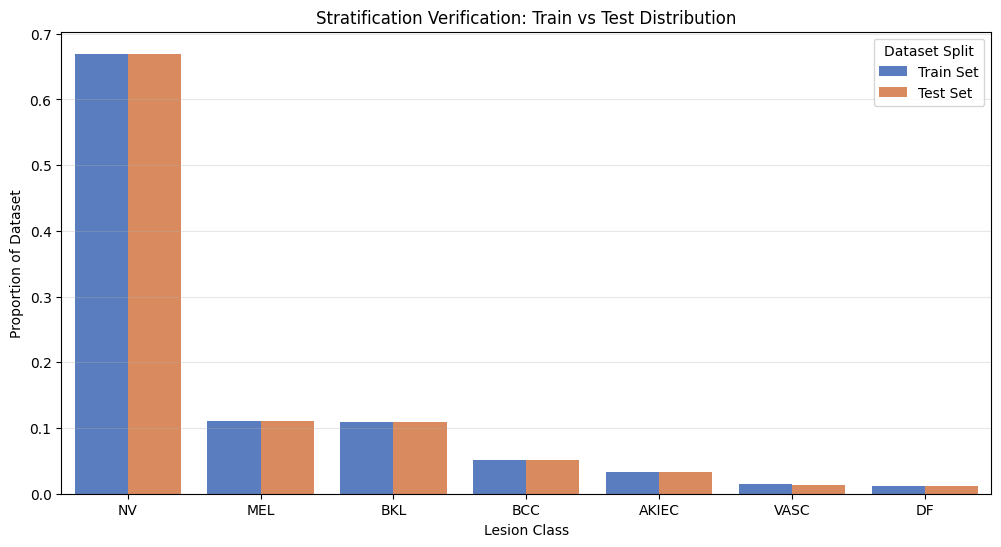


📝 THESIS CAPTION:
"Figure 3.1: Distribution of skin lesion classes across training and testing sets.
The stratification ensures that the minority classes (e.g., VASC, DF) are equally represented
in the test set, ensuring a realistic evaluation scenario."


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- 1. LOAD SPLITS ---
SPLIT_DIR = '/content/drive/MyDrive/FYP/splits'
train_path = os.path.join(SPLIT_DIR, 'train_split.csv')
test_path = os.path.join(SPLIT_DIR, 'test_split.csv')

if not os.path.exists(train_path) or not os.path.exists(test_path):
    print("❌ ERROR: Splits not found. Please run Block 2 (The Split) first.")
else:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    # --- 2. CALCULATE PERCENTAGES ---
    train_counts = train_df['label'].value_counts(normalize=True).rename('Train Set')
    test_counts = test_df['label'].value_counts(normalize=True).rename('Test Set')

    # Combine and FORCE index name to avoid KeyError
    comp_df = pd.concat([train_counts, test_counts], axis=1)
    comp_df.index.name = 'Lesion_Type'  # <--- FIX: We name it explicitly
    comp_df = comp_df.reset_index()     # Now the column is guaranteed to be 'Lesion_Type'

    # Melt using the explicit name
    comp_df = comp_df.melt(id_vars='Lesion_Type', var_name='Split', value_name='Percentage')

    # --- 3. THESIS TABLE GENERATOR ---
    print("\n📊 === THESIS TABLE: STRATIFICATION CHECK ===")
    print(f"{'Class':<10} | {'Train %':<10} | {'Test %':<10} | {'Status'}")
    print("-" * 50)

    # Re-access raw series for the table logic
    for cls in train_counts.index:
        tr_p = train_counts[cls] * 100
        te_p = test_counts.get(cls, 0) * 100
        diff = abs(tr_p - te_p)
        status = "✅ OK" if diff < 1.5 else "⚠️ DEVIATION"
        print(f"{cls:<10} | {tr_p:<9.2f}% | {te_p:<9.2f}% | {status}")

    # --- 4. VISUALIZATION ---
    plt.figure(figsize=(12, 6))
    # Update x-axis to match the new column name
    sns.barplot(data=comp_df, x='Lesion_Type', y='Percentage', hue='Split', palette='muted')
    plt.title("Stratification Verification: Train vs Test Distribution")
    plt.ylabel("Proportion of Dataset")
    plt.xlabel("Lesion Class")
    plt.grid(axis='y', alpha=0.3)
    plt.legend(title="Dataset Split")
    plt.show()

    print("\n📝 THESIS CAPTION:")
    print("\"Figure 3.1: Distribution of skin lesion classes across training and testing sets.")
    print("The stratification ensures that the minority classes (e.g., VASC, DF) are equally represented")
    print("in the test set, ensuring a realistic evaluation scenario.\"")

In [ ]:
# --- CLARIFICATION: COUNTS vs PROPORTIONS ---
print("\n📊 === THE REALITY CHECK: COUNTS vs PROPORTIONS ===")
print(f"{'Class':<10} | {'Train COUNT':<12} | {'Test COUNT':<12} | {'Train %':<8} | {'Test %':<8}")
print("-" * 65)

for cls in train_df['label'].unique():
    # Get Raw Counts
    tr_n = len(train_df[train_df['label'] == cls])
    te_n = len(test_df[test_df['label'] == cls])

    # Get Percentages
    tr_p = (tr_n / len(train_df)) * 100
    te_p = (te_n / len(test_df)) * 100

    print(f"{cls:<10} | {tr_n:<12} | {te_n:<12} | {tr_p:<7.1f}% | {te_p:<7.1f}%")

print(f"\n✅ Total Images -> Train: {len(train_df)} | Test: {len(test_df)}")
print("Notice: The COUNTS are very different, but the % is almost IDENTICAL.")


📊 === THE REALITY CHECK: COUNTS vs PROPORTIONS ===
Class      | Train COUNT  | Test COUNT   | Train %  | Test %  
-----------------------------------------------------------------
AKIEC      | 229          | 65           | 3.3    % | 3.2    %
NV         | 4693         | 1341         | 66.9   % | 66.9   %
BKL        | 769          | 220          | 11.0   % | 11.0   %
MEL        | 779          | 223          | 11.1   % | 11.1   %
BCC        | 360          | 103          | 5.1    % | 5.1    %
VASC       | 100          | 28           | 1.4    % | 1.4    %
DF         | 80           | 23           | 1.1    % | 1.1    %

✅ Total Images -> Train: 7010 | Test: 2003
Notice: The COUNTS are very different, but the % is almost IDENTICAL.
